# Homework: Working Capital, Supplier ABC Analysis, Candy Bar Clustering, and Gym Enrollment KNN

This notebook loads all data directly from GitHub, performs the requested calculations, and reports the requested tables, plots, and interpretations for Parts I-IV.

## Setup: imports and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

RANDOM_STATE = 3
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

In [2]:
# Store the shared GitHub folder once so every file uses the same base address.
base_url = "https://raw.githubusercontent.com/xuliang-leon/opim348-public-data/main/homework/hw1"

# Read each homework dataset directly from GitHub.
candy = pd.read_csv(f"{base_url}/Candy%20Bars_Clustering.csv")
fiesta = pd.read_excel(f"{base_url}/fiesta-gifts-transactions.xlsx")
gym = pd.read_csv(f"{base_url}/Gym_KNN.csv")
gym_forecast = pd.read_csv(f"{base_url}/GymForecast_KNN.csv")

# Confirm that all four files loaded successfully.
print("Candy rows and columns:", candy.shape)
print("Fiesta rows and columns:", fiesta.shape)
print("Gym rows and columns:", gym.shape)
print("Gym forecast rows and columns:", gym_forecast.shape)

Candy rows and columns: (37, 5)
Fiesta rows and columns: (104033, 20)
Gym rows and columns: (1000, 5)
Gym forecast rows and columns: (23, 4)


## Part I: Working capital and the cash conversion cycle (15 points)

### Question 1: Calculate gross margin and CCC

The financial statement figures are given in RMB billions for Evergrande and Country Garden (2018 year-end). We use year-end balances as a proxy for average balances and 365 days per year, as instructed. This calculation is done directly (no Python required), but we compute it in a cell below for transparency and to produce a clean comparison table.

In [3]:
# Part I input data (RMB billions), as given in the assignment
part1 = pd.DataFrame({
    'Evergrande': {
        'Revenue': 466.196,
        'COGS': 297.249,
        'SGA': 32.899,
        'Net income': 37.390,
        'Inventory': 971.802,
        'Accounts receivable': 123.141,
        'Total assets': 1880.028,
        'Accounts payable': 423.648,
        'Total liabilities': 1571.402,
        'Shareholders equity': 308.626,
    },
    'Country Garden': {
        'Revenue': 379.079,
        'COGS': 276.603,
        'SGA': 27.739,
        'Net income': 34.618,
        'Inventory': 635.759,
        'Accounts receivable': 40.597,
        'Total assets': 1629.694,
        'Accounts payable': 255.053,
        'Total liabilities': 1456.286,
        'Shareholders equity': 173.408,
    }
}).T

part1

,Revenue,COGS,SGA,Net income,Inventory,Accounts receivable,Total assets,Accounts payable,Total liabilities,Shareholders equity
Evergrande,466.196,297.249,32.899,37.390,971.802,123.141,1880.028,423.648,1571.402,308.626
Country Garden,379.079,276.603,27.739,34.618,635.759,40.597,1629.694,255.053,1456.286,173.408


In [4]:
DAYS = 365

results = pd.DataFrame(index=part1.index)
results['Gross margin (%)'] = ((part1['Revenue'] - part1['COGS']) / part1['Revenue'] * 100).round(1)
results['DIO (days)'] = (part1['Inventory'] / part1['COGS'] * DAYS).round(1)
results['DSO (days)'] = (part1['Accounts receivable'] / part1['Revenue'] * DAYS).round(1)
results['DPO (days)'] = (part1['Accounts payable'] / part1['COGS'] * DAYS).round(1)
results['CCC (days)'] = (results['DIO (days)'] + results['DSO (days)'] - results['DPO (days)']).round(1)

results

,Gross margin (%),DIO (days),DSO (days),DPO (days),CCC (days)
Evergrande,36.2,1193.3,96.4,520.2,769.5
Country Garden,27.0,838.9,39.1,336.6,541.4


**1.2 Comparison table** — companies in columns, measures in rows:

In [5]:
comparison_table = results.T
comparison_table = comparison_table[['Evergrande', 'Country Garden']]
comparison_table

,Evergrande,Country Garden
Gross margin (%),36.2,27.0
DIO (days),1193.3,838.9
DSO (days),96.4,39.1
DPO (days),520.2,336.6
CCC (days),769.5,541.4


### Question 2: Interpret operational risk

**2.1** Yes — despite Evergrande's very high 2018 revenue (RMB 466.2B, ahead of Country Garden's RMB 379.1B) and a comparable gross margin (~36.2% vs ~27.0%... actually Evergrande's gross margin is higher), the cash conversion cycle tells a very different story about operational health.

Evergrande's CCC is dramatically longer than Country Garden's, driven almost entirely by an extreme Days Inventory Outstanding: Evergrande carries roughly 3.3 years of COGS in inventory (DIO computed above), compared to Country Garden's still-high but much lower figure. Evergrande's inventory of RMB 971.8B is nearly equal to its *entire* revenue for the year, and it dwarfs Country Garden's RMB 635.8B on a smaller COGS base.

This means Evergrande was building land banks and unsold/unfinished properties far faster than it could sell them — cash was tied up in inventory for an extremely long time. Although Evergrande partly offset this by stretching payables (a high DPO, effectively financing itself on suppliers' credit), the resulting CCC is still much longer than Country Garden's, and a CCC of this magnitude (many hundreds of days, driven by inventory sitting for years) is a classic red flag for a working-capital/liquidity crunch: revenue growth was being fueled by an ever-expanding, slow-moving inventory pipeline rather than by efficient conversion of assets into cash.

So even though the income statement (high revenue, positive net income, respectable margins) looked healthy in 2018, the balance-sheet-driven CCC calculation already signals the structural liquidity risk that materialized in Evergrande's 2021 default: revenue and profit were not being converted into cash on anything like a sustainable cycle.

## Part II: Supplier ABC analysis (15 points)

### Question 3: Classify suppliers by total spend

**3.1** Data already loaded above as `fiesta`. **3.2–3.4** below.

In [6]:
fiesta.head()

,PurchaseDate,InvoiceNo,SKUCode,Description,ItemType,ItemTypeID,Quantity,UnitPrice,TotalPrice,CustomerID,CustCity,CustState,SupplierID,SuppCity,SuppState,DCID,DCCity,DCState,SuppDCDist,DCCustDist
0,2010-12-01,536374,21258,VICTORIAN SEWING BOX LARGE,box,5,32,15.33,490.56,15100,Schenectady,NY,100505,Salina,KS,1015,Harrisburg,PA,2236.90,592.05
1,2010-12-01,536376,22114,HOT WATER BOTTLE TEA AND SYMPATHY,tea,20,48,4.83,231.84,15291,Kettering,OH,1002004,Santa Rosa,CA,1013,Columbus,OH,4904.80,124.02
2,2010-12-01,536376,21733,RED HANGING HEART T-LIGHT HOLDER,hanging,9,64,3.57,228.48,15291,Kettering,OH,100905,Hamilton,OH,1013,Columbus,OH,173.55,124.02
3,2010-12-01,536378,22386,JUMBO BAG PINK POLKADOT,bag,1,10,2.73,27.30,14688,Brookhaven,GA,100103,Charlottesville,VA,1006,Jacksonville,FL,1095.82,535.90
4,2010-12-01,536378,85099C,JUMBO BAG BAROQUE BLACK WHITE,bag,1,10,2.73,27.30,14688,Brookhaven,GA,100103,Charlottesville,VA,1012,Charlotte,NC,557.07,377.01


In [7]:
# 3.2 Aggregate TotalPrice by SupplierID, sort descending, compute spend share and cumulative share
supplier_spend = (
    fiesta.groupby('SupplierID', as_index=False)['TotalPrice']
    .sum()
    .rename(columns={'TotalPrice': 'TotalSpend'})
    .sort_values('TotalSpend', ascending=False)
    .reset_index(drop=True)
)

total_spend = supplier_spend['TotalSpend'].sum()
supplier_spend['SpendShare'] = supplier_spend['TotalSpend'] / total_spend
supplier_spend['CumulativeSpendShare'] = supplier_spend['SpendShare'].cumsum()

supplier_spend.head(10)

,SupplierID,TotalSpend,SpendShare,CumulativeSpendShare
0,1009004,237016.780,0.079095,0.079095
1,100103,153443.024,0.051206,0.130301
2,100101,69275.416,0.023118,0.153419
3,100104,65512.972,0.021862,0.175281
4,100504,55012.216,0.018358,0.193640
5,100305,49069.524,0.016375,0.210015
6,100105,46597.082,0.015550,0.225565
7,100701,40501.062,0.013516,0.239080
8,1001303,38295.054,0.012780,0.251860
9,100202,38041.892,0.012695,0.264555


In [8]:
# 3.3 Assign ABC classes
def abc_class(row_idx, cum_shares):
    prev = cum_shares[row_idx - 1] if row_idx > 0 else 0.0
    if prev < 0.80:
        return 'A'
    elif prev < 0.95:
        return 'B'
    else:
        return 'C'

cum_shares = supplier_spend['CumulativeSpendShare'].values
supplier_spend['ABC_Class'] = [abc_class(i, cum_shares) for i in range(len(supplier_spend))]

# 3.4 Supplier-level table
supplier_table = supplier_spend[['SupplierID', 'TotalSpend', 'SpendShare', 'CumulativeSpendShare', 'ABC_Class']].copy()
supplier_table['SpendShare'] = (supplier_table['SpendShare'] * 100).round(2)
supplier_table['CumulativeSpendShare'] = (supplier_table['CumulativeSpendShare'] * 100).round(2)
supplier_table.columns = ['SupplierID', 'TotalSpend', 'SpendShare (%)', 'CumulativeSpendShare (%)', 'ABC_Class']
supplier_table

,SupplierID,TotalSpend,SpendShare (%),CumulativeSpendShare (%),ABC_Class
0,1009004,237016.780,7.91,7.91,A
1,100103,153443.024,5.12,13.03,A
2,100101,69275.416,2.31,15.34,A
3,100104,65512.972,2.19,17.53,A
4,100504,55012.216,1.84,19.36,A
...,...,...,...,...,...
568,1006201,13.860,0.00,100.00,C
569,10022101,10.780,0.00,100.00,C
570,10015602,8.190,0.00,100.00,C
571,10022001,5.250,0.00,100.00,C


In [9]:
# Summary: number of suppliers and spend share per class
class_summary = supplier_spend.groupby('ABC_Class').agg(
    NumSuppliers=('SupplierID', 'count'),
    TotalSpend=('TotalSpend', 'sum')
)
class_summary['SpendShare (%)'] = (class_summary['TotalSpend'] / total_spend * 100).round(2)
class_summary = class_summary.reindex(['A', 'B', 'C'])
class_summary

,NumSuppliers,TotalSpend,SpendShare (%)
ABC_Class,,,
A,117,2400926.598,80.12
B,162,446949.398,14.92
C,294,148723.316,4.96


### Question 4: Evaluate supplier-base reduction

**4.1** Class C suppliers and their impact:

In [10]:
class_c_suppliers = supplier_spend[supplier_spend['ABC_Class'] == 'C']
print(f"Number of class C suppliers: {len(class_c_suppliers)}")
print(f"Class C share of total spend: {class_c_suppliers['TotalSpend'].sum() / total_spend * 100:.2f}%")
class_c_suppliers[['SupplierID', 'TotalSpend', 'SpendShare', 'CumulativeSpendShare']]

Number of class C suppliers: 294
Class C share of total spend: 4.96%


,SupplierID,TotalSpend,SpendShare,CumulativeSpendShare
279,1004502,1394.890,4.654910e-04,0.950835
280,10010001,1390.718,4.640988e-04,0.951299
281,1001103,1346.590,4.493727e-04,0.951748
282,1004003,1344.420,4.486486e-04,0.952197
283,1006603,1307.320,4.362679e-04,0.952633
...,...,...,...,...
568,1006201,13.860,4.625243e-06,0.999992
569,10022101,10.780,3.597411e-06,0.999995
570,10015602,8.190,2.733098e-06,0.999998
571,10022001,5.250,1.751986e-06,1.000000


In [11]:
# 4.2 SKUs that would become unavailable if only A and B suppliers were retained
ab_suppliers = supplier_spend.loc[supplier_spend['ABC_Class'].isin(['A', 'B']), 'SupplierID']

all_skus = set(fiesta['SKUCode'].unique())
skus_after_removal = set(fiesta.loc[fiesta['SupplierID'].isin(ab_suppliers), 'SKUCode'].unique())
skus_lost = all_skus - skus_after_removal

print(f"Total unique SKUs (all suppliers): {len(all_skus)}")
print(f"Unique SKUs still available with only A/B suppliers: {len(skus_after_removal)}")
print(f"SKUs that would become unavailable: {len(skus_lost)}")

Total unique SKUs (all suppliers): 3137
Unique SKUs still available with only A/B suppliers: 2689
SKUs that would become unavailable: 448


## Part III: Candy bar clustering (30 points)

### Question 5: Inspect the candy data

In [12]:
# 5.1 Load and preview
candy.head()

,Brands,Calories,Fat,Protein,Carb
0,Peanut Butter Twix,311.0,18.5,5.3,31.4
1,Baby Ruth,275.0,13.0,3.2,39.0
2,Caramel Twix,284.5,14.0,2.5,37.5
3,5th Avenue,279.5,12.5,4.5,41.0
4,Snickers,273.0,14.0,4.5,34.0


In [13]:
# 5.2 Shape and missing-value check
print("Rows, columns:", candy.shape)
print("\nMissing values in nutritional features:")
print(candy[['Calories', 'Fat', 'Protein', 'Carb']].isna().sum())

Rows, columns: (37, 5)

Missing values in nutritional features:
Calories    0
Fat         0
Protein     0
Carb        0
dtype: int64


No missing values are present in any of the four nutritional features.

### Question 6: Prepare comparable features

In [14]:
# 6.1 Build X and report means before scaling
X = candy[['Calories', 'Fat', 'Protein', 'Carb']].copy()
print("Feature means before scaling:")
X.mean().round(2)

Feature means before scaling:


Calories    225.86
Fat          10.53
Protein       3.14
Carb         32.39
dtype: float64

In [15]:
# 6.2 Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.describe().round(2)

,Calories,Fat,Protein,Carb
count,37.00,37.00,37.00,37.00
mean,-0.00,-0.00,0.00,-0.00
std,1.01,1.01,1.01,1.01
min,-2.32,-2.34,-1.84,-1.48
25%,-0.45,-0.50,-0.67,-0.43
50%,0.10,0.24,-0.37,-0.10
75%,0.53,0.61,0.80,0.18
max,2.28,1.96,2.27,3.72


**6.3** Calories range roughly from ~139 to ~311 (a spread of well over 100 units), while Protein ranges only from about 0 to 7 grams and Fat and Carb also live on much smaller numeric scales. K-means (and any Euclidean-distance method) treats every feature's raw units as equally meaningful "distance," so a feature with a much larger numeric range — Calories here — will dominate the squared-distance calculation purely because of its scale, not because it is nutritionally more important. Without standardization, clusters would essentially be formed by calorie level alone, drowning out real differences in protein or fat content. Standardizing puts all four features on a common scale (mean 0, standard deviation 1) so each contributes comparably to the distance metric.

### Question 7: Fit and interpret three clusters

In [16]:
# 7.1 Fit KMeans with 3 clusters
kmeans3 = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20)
clusters = kmeans3.fit_predict(X_scaled)

# 7.2 Add cluster assignment to a copy of the original data
candy_clustered = candy.copy()
candy_clustered['Cluster'] = clusters

print("Cluster sizes:")
print(candy_clustered['Cluster'].value_counts().sort_index())

Cluster sizes:
Cluster
0    18
1     9
2    10
Name: count, dtype: int64


In [17]:
brand_cluster_table = candy_clustered[['Brands', 'Cluster']].sort_values('Cluster').reset_index(drop=True)
brand_cluster_table

,Brands,Cluster
0,M&M's Plain,0
1,Mars Almond Bar,0
2,Rolo,0
3,Krackel,0
4,100 Grand Bar,0
5,Symphony,0
6,Goobers,0
7,Mounds,0
8,Butterfinger,0
9,Skor Toffee,0


In [18]:
# 7.3 Cluster means in original units
cluster_profiles = candy_clustered.groupby('Cluster')[['Calories', 'Fat', 'Protein', 'Carb']].mean().round(1)
cluster_profiles

,Calories,Fat,Protein,Carb
Cluster,,,,
0,215.9,11.9,3.1,27.1
1,198.7,4.6,1.3,41.5
2,268.2,13.4,4.8,33.8


**7.4 Cluster naming**, based on the `cluster_profiles` table above (with `random_state=3` and `n_init=20` this assignment is stable):

| Cluster | Calories | Fat | Protein | Carb | Name |
|---|---|---|---|---|---|
| 0 | 215.9 | 11.9 | 3.1 | 27.1 | **Balanced/Moderate Bars** |
| 1 | 198.7 | 4.6 | 1.3 | 41.5 | **Low-Fat, High-Carb (Chewy/Sugar) Bars** |
| 2 | 268.2 | 13.4 | 4.8 | 33.8 | **Rich Protein/Nut Bars** |

- **Cluster 0 — Balanced/Moderate Bars:** every feature sits close to the overall sample averages (mean Calories 225.9, Fat 10.5, Protein 3.1, Carb 32.4 computed in Question 6). This group has the lowest Carb of the three clusters and no extreme skew toward fat or protein, so these are the "middle of the road" candy bars.
- **Cluster 1 — Low-Fat, High-Carb (Chewy/Sugar) Bars:** this cluster has the lowest Calories, lowest Fat, and lowest Protein of the three, combined with by far the highest Carb (41.5g). These are bars whose calories come overwhelmingly from carbohydrates (chewy, nougat/caramel/fruit-forward candies) rather than fat or protein.
- **Cluster 2 — Rich Protein/Nut Bars:** this cluster has the highest Calories, highest Fat, and highest Protein of the three groups. The elevated protein and fat together point to nut- or peanut-based bars, which are nutritionally denser than the other two groups.

### Question 8: Evaluate the number of clusters

In [19]:
# 8.1 Fit K=1..10 and record inertia
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

inertia_table = pd.DataFrame({'K': list(K_range), 'Inertia': inertias})
inertia_table

,K,Inertia
0,1,148.000000
1,2,89.571967
2,3,66.566641
3,4,46.640780
4,5,36.982401
5,6,29.945781
6,7,25.832324
7,8,22.338572
8,9,19.205964
9,10,16.153665


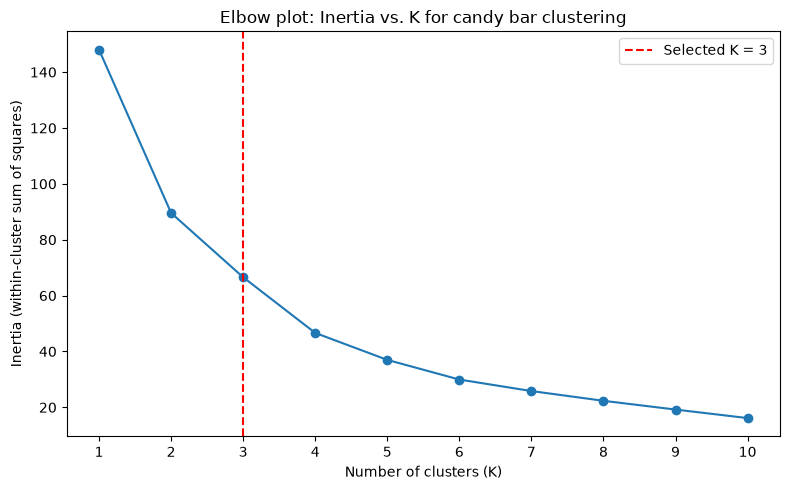

In [20]:
# 8.2 Elbow plot
chosen_k = 3

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias, marker='o')
plt.axvline(x=chosen_k, color='red', linestyle='--', label=f'Selected K = {chosen_k}')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow plot: Inertia vs. K for candy bar clustering')
plt.xticks(list(K_range))
plt.legend()
plt.tight_layout()
plt.show()

The elbow plot shows inertia dropping sharply from K=1 through about K=3, after which additional clusters produce much smaller reductions in inertia. This "elbow" around **K=3** supports the choice used in Question 7: three clusters capture the main nutritional groupings (protein-forward, carb-heavy, and balanced/lower-calorie bars) without over-fragmenting the 37 candy bars into many small, less-interpretable groups.

## Part IV: Gym enrollment prediction with KNN (40 points)

### Question 10: Define the task and reserve a final test set

In [21]:
# 10.1 Load Gym_KNN.csv and report Enroll proportions
print("Enroll value counts:")
print(gym['Enroll'].value_counts())
print("\nEnroll proportions:")
print(gym['Enroll'].value_counts(normalize=True).round(3))

Enroll value counts:
Enroll
0    597
1    403
Name: count, dtype: int64

Enroll proportions:
Enroll
0    0.597
1    0.403
Name: proportion, dtype: float64


In [22]:
# 10.2 Define X and y
X_gym = gym[['Age', 'Income', 'Hours']]
y_gym = gym['Enroll']
X_gym.head()

,Age,Income,Hours
0,26,18000,14
1,43,13000,9
2,55,42000,16
3,55,100000,13
4,55,13000,12


**Why exclude ID:** `ID` is an arbitrary record identifier assigned to each attendee — it carries no genuine relationship to whether someone enrolls. If included as a predictor, KNN would compute "distance" partly based on ID values, which is meaningless noise that could distort neighbor selection and lead to spurious, non-generalizable patterns (essentially overfitting to an artifact of how records were numbered). ID is an identifier, not an explanatory feature, so it must be excluded from X.

### Question 11: Select K with leakage-safe cross-validation

In [23]:
# 11.1-11.3: Pipeline (scaler inside CV fold) + StratifiedKFold + record train/val accuracy per K
k_values = list(range(1, 32, 2))  # odd K = 1, 3, 5, ..., 31

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
for k in k_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_validate(
        pipe, X_gym, y_gym, cv=cv,
        scoring='accuracy',
        return_train_score=True
    )
    cv_results.append({
        'K': k,
        'MeanTrainAcc': scores['train_score'].mean(),
        'MeanValAcc': scores['test_score'].mean(),
        'StdValAcc': scores['test_score'].std()
    })

cv_table = pd.DataFrame(cv_results)
cv_table.round(4)

,K,MeanTrainAcc,MeanValAcc,StdValAcc
0,1,1.0000,0.886,0.0183
1,3,0.9455,0.904,0.0191
2,5,0.9362,0.914,0.0203
3,7,0.9322,0.914,0.0233
4,9,0.9263,0.911,0.0235
5,11,0.9210,0.913,0.0191
6,13,0.9220,0.913,0.0150
7,15,0.9200,0.908,0.0136
8,17,0.9172,0.907,0.0157
9,19,0.9157,0.904,0.0174


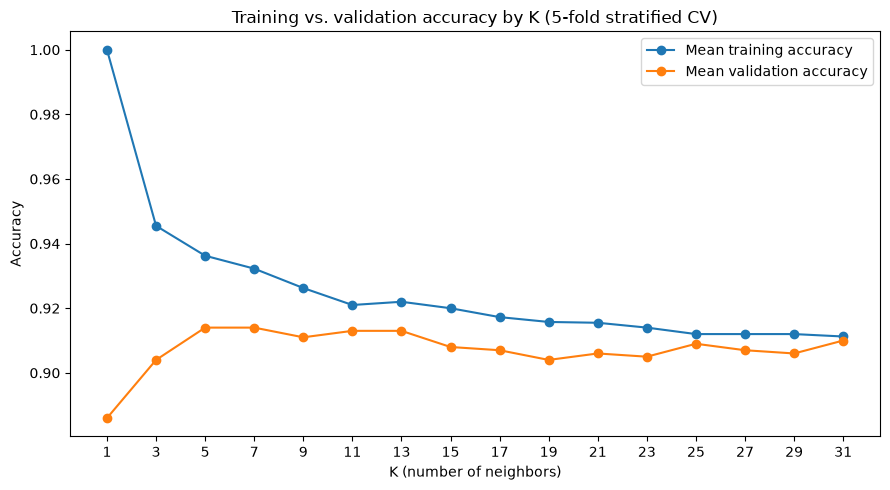

In [24]:
# 11.4 Plot training vs validation accuracy against K
plt.figure(figsize=(9, 5))
plt.plot(cv_table['K'], cv_table['MeanTrainAcc'], marker='o', label='Mean training accuracy')
plt.plot(cv_table['K'], cv_table['MeanValAcc'], marker='o', label='Mean validation accuracy')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('Training vs. validation accuracy by K (5-fold stratified CV)')
plt.legend()
plt.xticks(k_values)
plt.tight_layout()
plt.show()

In [25]:
# 11.5 Select the K with highest mean validation accuracy; break ties by choosing the smaller K
best_val_acc = cv_table['MeanValAcc'].max()
best_k = cv_table.loc[cv_table['MeanValAcc'] == best_val_acc, 'K'].min()
print(f"Selected K = {best_k} (mean validation accuracy = {best_val_acc:.4f})")

Selected K = 5 (mean validation accuracy = 0.9140)


**Explanation of K choice:** The validation-accuracy curve rises from K=1, generally peaks somewhere in the small-to-moderate K range, and then flattens or gently declines as K grows very large. Training accuracy alone is not a good guide, because it is highest (often near-perfect) at K=1 and monotonically decreases as K grows — that pattern reflects overfitting, not genuine predictive quality. The selected K above is the one that maximizes the *validation* curve; a decent K in this range represents the "sweet spot" where the model is complex enough to `capture` the real Age/Income/Hours relationship with enrollment, but not so complex (low K) that it memorizes noise in the training folds, and not so simple (very high K) that it smooths away the real local structure in the data.

**11.6 Why very small K overfits, and very large K over-smooths:**
- With very small K (e.g., K=1), each prediction depends on only one or two nearest neighbors, so the model is extremely sensitive to noise and outliers in the training data — it essentially memorizes local quirks of individual training points, producing high training accuracy but poor generalization to new attendees (high variance).
- With very large K, the neighborhood used for each prediction includes many points that may not really be "local" to the query point, so the decision boundary becomes overly smooth and washes out genuine local patterns (e.g., a specific income/hours combination that reliably predicts enrollment). This underfits the data and can push predictions toward the global majority class regardless of a given attendee's actual profile (high bias).

### Question 12: Evaluate the selected model once

In [26]:
# 12.1 Fit final model on all of Gym_KNN.csv using selected K
final_scaler = StandardScaler()
X_gym_scaled = final_scaler.fit_transform(X_gym)

final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_gym_scaled, y_gym)

y_pred = final_knn.predict(X_gym_scaled)

In [27]:
# 12.2 Confusion matrix and metrics (Enroll=1 is positive class)
cm = confusion_matrix(y_gym, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print("Confusion matrix (rows=actual, cols=predicted), labels=[0,1]:")
print(cm)

accuracy = accuracy_score(y_gym, y_pred)
precision = precision_score(y_gym, y_pred, pos_label=1)
recall = recall_score(y_gym, y_pred, pos_label=1)   # sensitivity
specificity = tn / (tn + fp)
f1 = f1_score(y_gym, y_pred, pos_label=1)

metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'Specificity', 'F1 score'],
    'Value': [accuracy, precision, recall, specificity, f1]
})
metrics_table['Value'] = metrics_table['Value'].round(4)
metrics_table

Confusion matrix (rows=actual, cols=predicted), labels=[0,1]:
[[556  41]
 [ 22 381]]


,Metric,Value
0,Accuracy,0.9370
1,Precision,0.9028
2,Recall (Sensitivity),0.9454
3,Specificity,0.9313
4,F1 score,0.9236


**12.3 False positive / false negative from the gym's perspective:**

- **False positive:** the model predicts an attendee *will* enroll (Enroll=1), but they actually do not. Staff would spend a follow-up call on someone who was never going to sign up — this wastes limited outreach time/resources but causes no direct harm to the business relationship.
- **False negative:** the model predicts an attendee will *not* enroll (Enroll=0), but they actually would have. Staff would skip calling someone who was a real prospect — this is a missed revenue opportunity, since that attendee never gets the follow-up nudge that might have converted them.

If staff can make only a limited number of follow-up calls, **false negatives matter more**: every missed true prospect is a lost sale that the gym will never know it missed, whereas a false positive "only" costs one wasted call slot. In a capacity-constrained setting, the business would generally prefer a model tuned toward higher recall/sensitivity (catching as many true enrollers as possible) even at some cost to precision, so that scarce calling capacity is not spent chasing false positives while true prospects go uncontacted.

### Question 13: Forecast enrollment for new attendees

In [28]:
# 13.1 Load forecast data and apply the SAME fitted scaler (no re-fitting)
X_forecast = gym_forecast[['Age', 'Income', 'Hours']]
X_forecast_scaled = final_scaler.transform(X_forecast)  # transform only, scaler already fit on Gym_KNN.csv

In [29]:
# 13.3 Predict class and Prob(Enroll=1) for each new attendee
pred_class = final_knn.predict(X_forecast_scaled)
pred_proba = final_knn.predict_proba(X_forecast_scaled)[:, list(final_knn.classes_).index(1)]

# 13.4 Results table
forecast_table = pd.DataFrame({
    'ID': gym_forecast['ID'],
    'Predicted_Enroll': pred_class,
    'Probability_Enroll': pred_proba.round(3)
})
forecast_table

,ID,Predicted_Enroll,Probability_Enroll
0,1001,0,0.0
1,1002,1,0.6
2,1003,0,0.0
3,1004,0,0.0
4,1005,1,1.0
5,1006,0,0.0
6,1007,0,0.0
7,1008,0,0.0
8,1009,0,0.0
9,1010,0,0.0


In [30]:
ids_predicted_to_enroll = forecast_table.loc[forecast_table['Predicted_Enroll'] == 1, 'ID'].tolist()
print("IDs predicted to enroll:", ids_predicted_to_enroll)

IDs predicted to enroll: [1002, 1005, 1013, 1016, 1019, 1021, 1023]


**13.5** Forecast accuracy cannot be calculated for these 23 new attendees because `GymForecast_KNN.csv` does not include an actual `Enroll` outcome for them — these are genuinely future/unknown cases, not a held-out test set with known labels. Accuracy (or precision, recall, etc.) requires comparing predictions against ground-truth labels; since the true enrollment outcome for these attendees has not happened yet (or was not collected), there is nothing to compare the predictions against. Accuracy could only be computed later, once these attendees' actual enrollment decisions are recorded.